In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [7]:
data = pd.read_csv("cleanchurn.csv")

In [8]:
df = pd.DataFrame(data)
df

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7038,6840-RESVB,Male,no,Yes,Yes,24,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,7039,2234-XADUH,Female,no,Yes,Yes,72,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,7040,4801-JZAZL,Female,no,Yes,Yes,11,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,7041,8361-LTMKD,Male,yes,Yes,No,4,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [9]:
# Features
X = df.drop(columns=["Unnamed: 0", "customerID", "Churn"])

# Target
y = df["Churn"].map({"No": 0, "Yes": 1})
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

print("\nTarget Distribution:")
print(y.value_counts())

Features Shape : (7043, 19)
Target Shape   : (7043,)

Feature Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [10]:
print(df["Churn"].unique())
print(df["Churn"].dtype)

['No' 'Yes']
object


In [11]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)


Training Features : (5634, 19)
Testing Features  : (1409, 19)
Training Target   : (5634,)
Testing Target    : (1409,)


In [12]:
print("Training Set:")
print(y_train.value_counts(normalize=True))

print("\nTesting Set:")
print(y_test.value_counts(normalize=True))

Training Set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing Set:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [13]:
# Numerical columns
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Categorical columns
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


#identifying categorical and numerical features


In [14]:
#building a preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

#preprocessed categories into onehotencoder and standardscaler

we will use logistic regression first because it is a baseline model for binary classification

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

In [16]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [17]:
# Get the fitted preprocessor
fitted_preprocessor = pipeline.named_steps["preprocessor"]

# Get all transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of original features:", X_train.shape[1])
print("Number of transformed features:", len(feature_names))

print("\nFirst 20 transformed features:\n")
for feature in feature_names[:20]:
    print(feature)

Number of original features: 19
Number of transformed features: 46

First 20 transformed features:

cat__gender_Female
cat__gender_Male
cat__SeniorCitizen_no
cat__SeniorCitizen_yes
cat__Partner_No
cat__Partner_Yes
cat__Dependents_No
cat__Dependents_Yes
cat__PhoneService_No
cat__PhoneService_Yes
cat__MultipleLines_No
cat__MultipleLines_No phone service
cat__MultipleLines_Yes
cat__InternetService_DSL
cat__InternetService_Fiber optic
cat__InternetService_No
cat__OnlineSecurity_No
cat__OnlineSecurity_No internet service
cat__OnlineSecurity_Yes
cat__OnlineBackup_No


In [18]:
X_train_transformed = fitted_preprocessor.transform(X_train)

print(X_train_transformed.shape)

(5634, 46)


In [19]:
#converting it back to a dataframe
X_train_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

X_train_df.head()

,cat__gender_Female,cat__gender_Male,cat__SeniorCitizen_no,cat__SeniorCitizen_yes,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__PhoneService_No,cat__PhoneService_Yes,...,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,num__tenure,num__MonthlyCharges,num__TotalCharges
0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.102371,-0.521976,-0.262257
1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.711743,0.337478,-0.503635
2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.793155,-0.809013,-0.749883
3,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,-0.263980,0.284384,-0.172722
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-1.281624,-0.676279,-0.989374


In [20]:
#predicting on data that the model has never seen
y_pred = pipeline.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [165 209]]


In [22]:
#probability prediction
y_prob = pipeline.predict_proba(X_test)
print(y_prob[:20])

[[0.95394143 0.04605857]
 [0.31635212 0.68364788]
 [0.94127458 0.05872542]
 [0.59887974 0.40112026]
 [0.97836261 0.02163739]
 [0.39685365 0.60314635]
 [0.55246901 0.44753099]
 [0.86980601 0.13019399]
 [0.99715124 0.00284876]
 [0.6044584  0.3955416 ]
 [0.73144123 0.26855877]
 [0.93731194 0.06268806]
 [0.8710458  0.1289542 ]
 [0.31390672 0.68609328]
 [0.87132419 0.12867581]
 [0.94161457 0.05838543]
 [0.96726542 0.03273458]
 [0.36300192 0.63699808]
 [0.81982152 0.18017848]
 [0.91522384 0.08477616]]


In [23]:
y_prob = pipeline.predict_proba(X_test)[:,1]
print(y_prob[:10])
print(y_prob.shape)

[0.04605857 0.68364788 0.05872542 0.40112026 0.02163739 0.60314635
 0.44753099 0.13019399 0.00284876 0.3955416 ]
(1409,)


In [24]:
# Threshold = 0.3
threshold = 0.3

y_pred_03 = (y_prob >= threshold).astype(int)


In [25]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_03))

print("\nAccuracy :", accuracy_score(y_test, y_pred_03))
print("Precision:", precision_score(y_test, y_pred_03))
print("Recall   :", recall_score(y_test, y_pred_03))
print("F1 Score :", f1_score(y_test, y_pred_03))

Confusion Matrix:
[[774 261]
 [ 92 282]]

Accuracy : 0.7494677075940384
Precision: 0.5193370165745856
Recall   : 0.7540106951871658
F1 Score : 0.6150490730643402


In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get churn probabilities
y_prob = pipeline.predict_proba(X_test)[:, 1]

# ROC Curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.8420341522643313


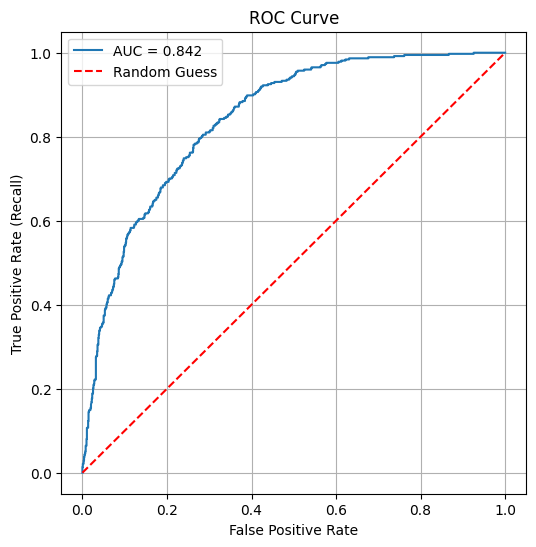

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# ROC Curve
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

# Random Guess Line
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

#lets compare weather if decision tree would be a better option then logistic regression

In [28]:
from sklearn.tree import DecisionTreeClassifier

#creating new pipeline

In [29]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [30]:
#training the model
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [31]:
#make predictions
y_pred_dt = dt_pipeline.predict(X_test)


In [32]:
#lets evalute it 
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

cm = confusion_matrix(y_test, y_pred_dt)

accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

auc_dt = roc_auc_score(y_test, y_prob_dt)

print("AUC:", auc_dt)



print(cm)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

AUC: 0.6473042444909453
[[834 201]
 [191 183]]
Accuracy : 0.7217885024840313
Precision: 0.4765625
Recall   : 0.4893048128342246
F1 Score : 0.48284960422163586


In [33]:
print("y_test unique:", np.unique(y_test))
print("y_pred_dt unique:", np.unique(y_pred_dt))

print("y_test dtype:", y_test.dtype)
print("y_pred_dt dtype:", y_pred_dt.dtype)

y_test unique: [0 1]
y_pred_dt unique: [0 1]
y_test dtype: int64
y_pred_dt dtype: int64


#comparitivly logistic regression still leads with better accuracy, precesion , recall, and auc rate than decision tree

#lets take one more model known as random forest

In [34]:
#importing random forest
from sklearn.ensemble import RandomForestClassifier

In [35]:
#creating pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators = 100,
        random_state = 42
    ))
])

In [36]:
#train
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [37]:
#predict
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]



In [38]:
#lets evalute
cm = confusion_matrix(y_test, y_pred_rf)
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
auc = roc_auc_score(y_test, y_prob_rf)

print(cm)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC      :", auc)

[[924 111]
 [191 183]]
Accuracy : 0.7856635911994322
Precision: 0.6224489795918368
Recall   : 0.4893048128342246
F1 Score : 0.5479041916167665
AUC      : 0.8202226872303598


#lets take another model known as XGBoost

In [39]:
import xgboost
print(xgboost.__version__)

3.0.2


In [40]:
from xgboost import XGBClassifier

In [41]:
xg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state = 42,
        eval_metric = "logloss"
    ))
])

In [42]:
#train

xg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [43]:
#predict
y_pred_xgb = xg_pipeline.predict(X_test)
y_prob_xgb = xg_pipeline.predict_proba(X_test)[:, 1]

In [44]:
#evalution
cm = confusion_matrix(y_test, y_pred_xgb)

accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
auc = roc_auc_score(y_test, y_prob_xgb)

print(cm)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC      :", auc)

[[913 122]
 [183 191]]
Accuracy : 0.7835344215755855
Precision: 0.610223642172524
Recall   : 0.5106951871657754
F1 Score : 0.5560407569141194
AUC      : 0.8185176573923377


#still logistic regression so far the best model

lets cross validate for logistic model

In [45]:
from sklearn.model_selection import cross_val_score

In [46]:
#logistic regression
cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

#Decision Tree
dt_cv = cross_val_score(
    dt_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

#Random Forest
rf_cv = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

#xgboost
xgb_cv = cross_val_score(
    xg_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(xgb_cv)
print("Mean AUC:", xgb_cv.mean())

print(rf_cv)
print("Mean AUC:", rf_cv.mean())
print(dt_cv)
print("Mean AUC:", dt_cv.mean())

print(cv_scores)
print("Mean AUC:", cv_scores.mean())

[0.82439743 0.83824821 0.80222687 0.8167787  0.82020139]
Mean AUC: 0.8203705191407125
[0.83353484 0.83060141 0.79951045 0.80812708 0.81784178]
Mean AUC: 0.8179231105697046
[0.63832055 0.67560128 0.64742308 0.64236702 0.65311236]
Mean AUC: 0.6513648577277442
[0.85814927 0.85854969 0.83308404 0.83803085 0.83884815]
Mean AUC: 0.8453323987378946


lets use gridsearch for hyperparameter

In [47]:
from sklearn.model_selection import GridSearchCV

In [48]:
#defining the parameter grid
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"]
}

In [49]:
#creating grid search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [50]:
#training
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'SeniorCitizen',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges'])])),
                                       ('classifier',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['liblinear']},
             scoring='roc_auc')

In [51]:
#results
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV Score: 0.845967281639525


In [53]:
grid_search.best_estimator_


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classifier',
                 LogisticRegression(C=10, random_state=42,
                                    solver='liblinear'))])

In [54]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [55]:
best_model.predict(X_test)

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

In [56]:
#evaluating the tuned model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8048261178140526
Precision: 0.6551724137931034
Recall   : 0.5588235294117647
F1 Score : 0.6031746031746031
ROC AUC  : 0.8412694722157638

Confusion Matrix
[[925 110]
 [165 209]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [64]:
#lets move to feature importance using logistic regression
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = best_model.named_steps["classifier"].coef_[0]


In [65]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df.head()

,Feature,Coefficient
0,cat__gender_Female,-0.217428
1,cat__gender_Male,-0.193838
2,cat__SeniorCitizen_no,-0.278601
3,cat__SeniorCitizen_yes,-0.132665
4,cat__Partner_No,-0.216498


In [66]:
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient
14,cat__InternetService_Fiber optic,1.312993
45,num__TotalCharges,0.577842
34,cat__Contract_Month-to-month,0.552603
33,cat__StreamingMovies_Yes,0.528334
30,cat__StreamingTV_Yes,0.527907
12,cat__MultipleLines_Yes,0.341364
24,cat__DeviceProtection_Yes,0.231597
41,cat__PaymentMethod_Electronic check,0.173630
21,cat__OnlineBackup_Yes,0.162405
16,cat__OnlineSecurity_No,0.136175


In [67]:
coef_df.tail(10)

,Feature,Coefficient
23,cat__DeviceProtection_No internet service,-0.587237
20,cat__OnlineBackup_No internet service,-0.587237
15,cat__InternetService_No,-0.587237
17,cat__OnlineSecurity_No internet service,-0.587237
29,cat__StreamingTV_No internet service,-0.587237
32,cat__StreamingMovies_No internet service,-0.587237
36,cat__Contract_Two year,-0.817984
13,cat__InternetService_DSL,-1.137022
43,num__tenure,-1.299635
44,num__MonthlyCharges,-2.001057


In [68]:
#evaluting using Random Forest
feature_names = preprocessor.get_feature_names_out()

importances = rf_pipeline.named_steps["classifier"].feature_importances_

In [69]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = rf_pipeline.named_steps["classifier"].feature_importances_

In [70]:
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [71]:
rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

In [72]:
rf_importance.head(10)

,Feature,Importance
45,num__TotalCharges,0.159636
43,num__tenure,0.138694
44,num__MonthlyCharges,0.137158
34,cat__Contract_Month-to-month,0.048625
41,cat__PaymentMethod_Electronic check,0.030737
16,cat__OnlineSecurity_No,0.026472
14,cat__InternetService_Fiber optic,0.024871
25,cat__TechSupport_No,0.024685
19,cat__OnlineBackup_No,0.018612
0,cat__gender_Female,0.017914


In [73]:
#feature evalution with xgboost
feature_names = xg_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = xg_pipeline.named_steps["classifier"].feature_importances_

xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

xgb_importance.head(10)

,Feature,Importance
14,cat__InternetService_Fiber optic,0.358682
34,cat__Contract_Month-to-month,0.341235
33,cat__StreamingMovies_Yes,0.018794
16,cat__OnlineSecurity_No,0.017872
36,cat__Contract_Two year,0.017505
25,cat__TechSupport_No,0.017465
35,cat__Contract_One year,0.016495
8,cat__PhoneService_No,0.013696
43,num__tenure,0.011968
10,cat__MultipleLines_No,0.011852


In [74]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 1.26.4

   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
    Uninstalling numpy-1.26.4:
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.2.6 which is incompatible.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.2.6 which is incompatible.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 6.32.0 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.16.1 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.32